In [56]:
from datasets import load_dataset

ds = load_dataset("ScaleAI/researchrubrics")


In [57]:
import pandas as pd

df = pd.DataFrame(ds["train"])

df.head()


,prompt,sample_id,domain,conceptual_breadth,logical_nesting,exploration,rubrics
0,"I want to create a plan for July 4, 2025, i.e....",6847465956a0f6376a605427,Current Events,Simple,Intermediate,Medium,[{'criterion': 'The response covers the period...
1,Act as a creative technical founder and brains...,6847465956a0f6376a605433,Business Planning & Research,Moderate,Intermediate,High,[{'criterion': 'The response provides exactly ...
2,Write a synthesis report on the applications o...,6847465956a0f6376a605355,AI & ML,Moderate,Intermediate,Medium,"[{'criterion': 'The response, for each stage, ..."
3,Critically analyze how agricultural practices ...,6847465956a0f6376a6054d0,Historical Analysis,Moderate,Intermediate,Medium,[{'criterion': 'The response discusses how Nil...
4,"I am a software engineer at a small startup, t...",6847465956a0f6376a60542a,Technical Documentation,Moderate,Intermediate,Medium,[{'criterion': 'The response discusses the lim...


In [58]:
# Basic dataset info
print("Dataset shape:", df.shape)
print("\nColumn names:", df.columns.tolist())
print("\nData types:")
print(df.dtypes)
print("\nFirst few rows:")
df.head()


Dataset shape: (101, 7)

Column names: ['prompt', 'sample_id', 'domain', 'conceptual_breadth', 'logical_nesting', 'exploration', 'rubrics']

Data types:
prompt                object
sample_id             object
domain                object
conceptual_breadth    object
logical_nesting       object
exploration           object
rubrics               object
dtype: object

First few rows:


,prompt,sample_id,domain,conceptual_breadth,logical_nesting,exploration,rubrics
0,"I want to create a plan for July 4, 2025, i.e....",6847465956a0f6376a605427,Current Events,Simple,Intermediate,Medium,[{'criterion': 'The response covers the period...
1,Act as a creative technical founder and brains...,6847465956a0f6376a605433,Business Planning & Research,Moderate,Intermediate,High,[{'criterion': 'The response provides exactly ...
2,Write a synthesis report on the applications o...,6847465956a0f6376a605355,AI & ML,Moderate,Intermediate,Medium,"[{'criterion': 'The response, for each stage, ..."
3,Critically analyze how agricultural practices ...,6847465956a0f6376a6054d0,Historical Analysis,Moderate,Intermediate,Medium,[{'criterion': 'The response discusses how Nil...
4,"I am a software engineer at a small startup, t...",6847465956a0f6376a60542a,Technical Documentation,Moderate,Intermediate,Medium,[{'criterion': 'The response discusses the lim...


In [59]:
# Explore structure of each column
for col in df.columns:
    print(f"\n{'='*60}")
    print(f"Column: {col}")
    print(f"{'='*60}")
    print(f"Type: {df[col].dtype}")
    print(f"Non-null count: {df[col].notna().sum()}/{len(df)}")
    
    # Show sample values
    sample_val = df[col].iloc[0] if len(df) > 0 else None
    if sample_val is not None:
        print(f"\nSample value (first row):")
        if isinstance(sample_val, (dict, list)):
            print(f"Type: {type(sample_val)}")
            if isinstance(sample_val, dict):
                print(f"Keys: {list(sample_val.keys())[:10]}")
            elif isinstance(sample_val, list):
                print(f"Length: {len(sample_val)}")
                if len(sample_val) > 0:
                    print(f"First item type: {type(sample_val[0])}")
        else:
            print(sample_val)



Column: prompt
Type: object
Non-null count: 101/101

Sample value (first row):
I want to create a plan for July 4, 2025, i.e., Independence Day in Washington DC. I would like an itinerary of all the things to do and all the activities that are planned for Independence Day. Create a plan for the whole day and also extend it to the weekend, if required. Provide some reviews or explain why one should visit the place or engage in the activity. Add any additional information that is required.

Column: sample_id
Type: object
Non-null count: 101/101

Sample value (first row):
6847465956a0f6376a605427

Column: domain
Type: object
Non-null count: 101/101

Sample value (first row):
Current Events

Column: conceptual_breadth
Type: object
Non-null count: 101/101

Sample value (first row):
Simple

Column: logical_nesting
Type: object
Non-null count: 101/101

Sample value (first row):
Intermediate

Column: exploration
Type: object
Non-null count: 101/101

Sample value (first row):
Medium

Column: r

In [60]:
# Number of rubrics per question
# Assuming there's a question/query field and rubrics field
question_cols = [col for col in df.columns if 'question' in col.lower() or 'query' in col.lower() or 'prompt' in col.lower()]
rubric_cols = [col for col in df.columns if 'rubric' in col.lower() or 'criteria' in col.lower()]

print("Question-related columns:", question_cols)
print("Rubric-related columns:", rubric_cols)

# Try to find rubrics per question
if rubric_cols:
    for col in rubric_cols:
        if df[col].dtype == 'object':
            # Check if it's a list/dict structure
            sample = df[col].iloc[0]
            if isinstance(sample, list):
                df['num_rubrics'] = df[col].apply(lambda x: len(x) if isinstance(x, list) else 0)
                print(f"\nRubrics per question (from {col}):")
                print(df['num_rubrics'].describe())
                print(f"\nDistribution:")
                print(df['num_rubrics'].value_counts().sort_index())
            elif isinstance(sample, dict):
                # Try to find nested lists
                def count_rubrics(x):
                    if isinstance(x, dict):
                        # Look for common keys that might contain rubrics
                        for key in ['rubrics', 'criteria', 'stages', 'rules']:
                            if key in x and isinstance(x[key], list):
                                return len(x[key])
                        # Count top-level items if it's a structured rubric
                        return len(x) if x else 0
                    return 0
                df['num_rubrics'] = df[col].apply(count_rubrics)
                if df['num_rubrics'].sum() > 0:
                    print(f"\nRubrics per question (from {col}):")
                    print(df['num_rubrics'].describe())
                    print(f"\nDistribution:")
                    print(df['num_rubrics'].value_counts().sort_index())


Question-related columns: ['prompt']
Rubric-related columns: ['rubrics']

Rubrics per question (from rubrics):
count    101.000000
mean      25.673267
std        4.847905
min       20.000000
25%       22.000000
50%       24.000000
75%       28.000000
max       43.000000
Name: num_rubrics, dtype: float64

Distribution:
num_rubrics
20     9
21    15
22    12
23     7
24     8
25     6
26     6
27     3
28    10
29     3
30     4
31     4
32     1
33     6
34     5
40     1
43     1
Name: count, dtype: int64



Question length statistics (from prompt):
Character length:
count     101.000000
mean      555.346535
std       365.971568
min       102.000000
25%       310.000000
50%       432.000000
75%       751.000000
max      1747.000000
Name: prompt_length, dtype: float64

Word count:
count    101.000000
mean      87.613861
std       58.897873
min       13.000000
25%       48.000000
50%       68.000000
75%      114.000000
max      315.000000
Name: prompt_word_count, dtype: float64


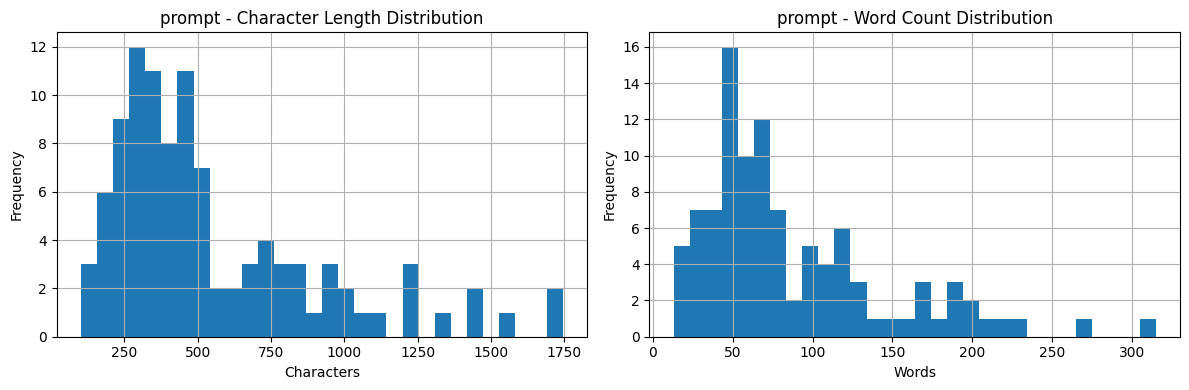

In [61]:
# Average length of questions
if question_cols:
    for col in question_cols:
        if df[col].dtype == 'object':
            df[f'{col}_length'] = df[col].astype(str).apply(len)
            df[f'{col}_word_count'] = df[col].astype(str).apply(lambda x: len(x.split()))
            
            print(f"\nQuestion length statistics (from {col}):")
            print(f"Character length:")
            print(df[f'{col}_length'].describe())
            print(f"\nWord count:")
            print(df[f'{col}_word_count'].describe())
            
            # Show distribution
            import matplotlib.pyplot as plt
            fig, axes = plt.subplots(1, 2, figsize=(12, 4))
            df[f'{col}_length'].hist(bins=30, ax=axes[0])
            axes[0].set_title(f'{col} - Character Length Distribution')
            axes[0].set_xlabel('Characters')
            axes[0].set_ylabel('Frequency')
            
            df[f'{col}_word_count'].hist(bins=30, ax=axes[1])
            axes[1].set_title(f'{col} - Word Count Distribution')
            axes[1].set_xlabel('Words')
            axes[1].set_ylabel('Frequency')
            plt.tight_layout()
            plt.show()


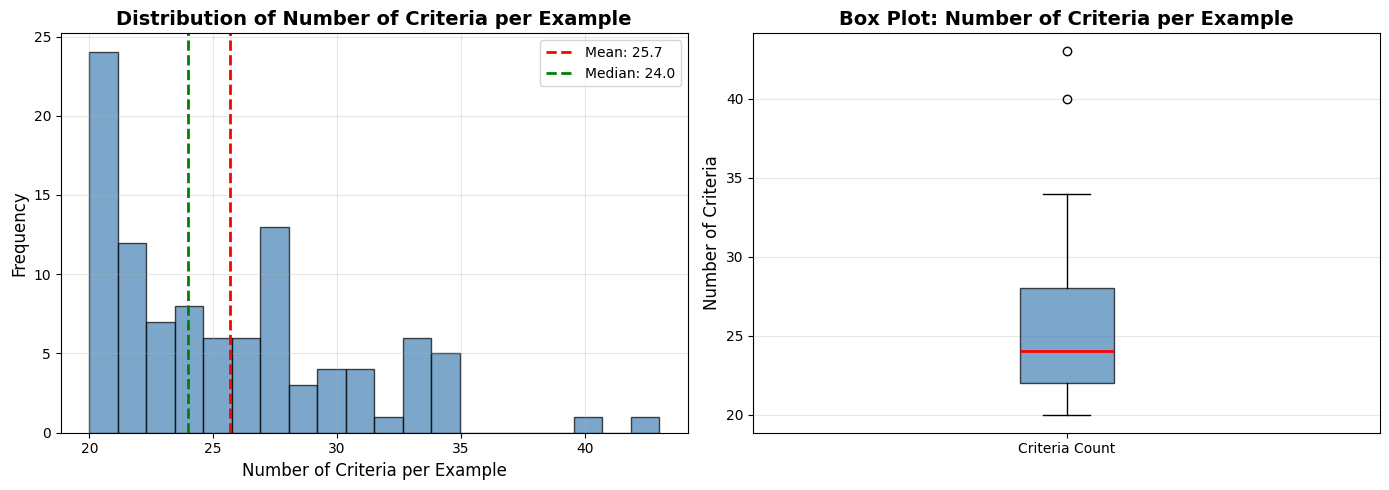


Summary Statistics:
  Mean: 25.67
  Median: 24.00
  Std Dev: 4.85
  Min: 20
  Max: 43


In [62]:
# Visualization: Number of criteria per example
import matplotlib.pyplot as plt
import numpy as np

if 'num_rubrics' in df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Histogram
    axes[0].hist(df['num_rubrics'], bins=20, edgecolor='black', alpha=0.7, color='steelblue')
    axes[0].axvline(df['num_rubrics'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {df["num_rubrics"].mean():.1f}')
    axes[0].axvline(df['num_rubrics'].median(), color='green', linestyle='--', linewidth=2, label=f'Median: {df["num_rubrics"].median():.1f}')
    axes[0].set_xlabel('Number of Criteria per Example', fontsize=12)
    axes[0].set_ylabel('Frequency', fontsize=12)
    axes[0].set_title('Distribution of Number of Criteria per Example', fontsize=14, fontweight='bold')
    axes[0].legend()
    axes[0].grid(alpha=0.3)
    
    # Box plot
    bp = axes[1].boxplot(df['num_rubrics'], vert=True, patch_artist=True, 
                         boxprops=dict(facecolor='steelblue', alpha=0.7),
                         medianprops=dict(color='red', linewidth=2))
    axes[1].set_ylabel('Number of Criteria', fontsize=12)
    axes[1].set_title('Box Plot: Number of Criteria per Example', fontsize=14, fontweight='bold')
    axes[1].grid(alpha=0.3, axis='y')
    axes[1].set_xticklabels(['Criteria Count'])
    
    plt.tight_layout()
    plt.show()
    
    # Print summary statistics
    print(f"\nSummary Statistics:")
    print(f"  Mean: {df['num_rubrics'].mean():.2f}")
    print(f"  Median: {df['num_rubrics'].median():.2f}")
    print(f"  Std Dev: {df['num_rubrics'].std():.2f}")
    print(f"  Min: {df['num_rubrics'].min()}")
    print(f"  Max: {df['num_rubrics'].max()}")
else:
    print("num_rubrics column not found. Please run the previous cells first.")


In [63]:
# Different values for rubric criteria
# Explore rubric structure and extract criteria information
if rubric_cols:
    for col in rubric_cols:
        print(f"\n{'='*60}")
        print(f"Exploring rubric criteria from: {col}")
        print(f"{'='*60}")
        
        sample = df[col].iloc[0]
        
        if isinstance(sample, dict):
            # Extract all unique keys across all rubrics
            all_keys = set()
            for item in df[col]:
                if isinstance(item, dict):
                    all_keys.update(item.keys())
            
            print(f"\nTop-level keys found: {sorted(all_keys)}")
            
            # Explore common rubric structure fields
            for key in ['criteria', 'stages', 'rules', 'category', 'type', 'domain']:
                if key in all_keys:
                    values = []
                    for item in df[col]:
                        if isinstance(item, dict) and key in item:
                            val = item[key]
                            if isinstance(val, list):
                                values.extend([str(v) for v in val])
                            else:
                                values.append(str(val))
                    
                    if values:
                        print(f"\nUnique values for '{key}':")
                        from collections import Counter
                        value_counts = Counter(values)
                        for val, count in value_counts.most_common(20):
                            print(f"  {val}: {count}")
        
        elif isinstance(sample, list):
            # If rubrics are stored as a list
            print(f"\nRubrics are stored as lists of length {len(sample)}")
            if len(sample) > 0:
                print(f"First rubric type: {type(sample[0])}")
                if isinstance(sample[0], dict):
                    all_keys = set()
                    for rubric_list in df[col]:
                        if isinstance(rubric_list, list):
                            for rubric in rubric_list:
                                if isinstance(rubric, dict):
                                    all_keys.update(rubric.keys())
                    print(f"Keys found in rubric items: {sorted(all_keys)}")



Exploring rubric criteria from: rubrics

Rubrics are stored as lists of length 21
First rubric type: <class 'dict'>
Keys found in rubric items: ['axis', 'criterion', 'weight']


In [64]:
# Number of domains
domain_cols = [col for col in df.columns if 'domain' in col.lower() or 'category' in col.lower() or 'sector' in col.lower()]

print("Domain/category-related columns:", domain_cols)

if domain_cols:
    for col in domain_cols:
        print(f"\n{'='*60}")
        print(f"Domain analysis (from {col}):")
        print(f"{'='*60}")
        
        if df[col].dtype == 'object':
            # Check if it's a simple string column or nested
            sample = df[col].iloc[0]
            
            if isinstance(sample, str):
                print(f"\nNumber of unique domains: {df[col].nunique()}")
                print(f"\nDomain distribution:")
                print(df[col].value_counts())
            elif isinstance(sample, (list, dict)):
                # Extract domains from nested structures
                domains = []
                for item in df[col]:
                    if isinstance(item, list):
                        domains.extend([str(d) for d in item])
                    elif isinstance(item, dict):
                        # Look for domain-related keys
                        for key in ['domain', 'category', 'sector', 'type']:
                            if key in item:
                                domains.append(str(item[key]))
                
                if domains:
                    from collections import Counter
                    domain_counts = Counter(domains)
                    print(f"\nNumber of unique domains: {len(domain_counts)}")
                    print(f"\nDomain distribution:")
                    for domain, count in domain_counts.most_common():
                        print(f"  {domain}: {count}")
else:
    print("\nNo explicit domain column found. Checking other categorical columns...")
    categorical_cols = df.select_dtypes(include=['object']).columns
    for col in categorical_cols[:5]:  # Check first 5 categorical columns
        if df[col].nunique() < 50:  # Reasonable number of categories
            print(f"\n{col} (nunique={df[col].nunique()}):")
            print(df[col].value_counts().head(10))


Domain/category-related columns: ['domain']

Domain analysis (from domain):

Number of unique domains: 10

Domain distribution:
domain
AI & ML                         17
Historical Analysis             13
Business Planning & Research    12
Technical Documentation         12
General Consumer Research       11
Hypotheticals & Philosophy      11
STEM                             8
Creative Writing                 6
Other                            6
Current Events                   5
Name: count, dtype: int64


In [65]:
# Additional EDA: Missing values, summary statistics
print("Missing values per column:")
print(df.isnull().sum())
print(f"\nPercentage missing:")
print((df.isnull().sum() / len(df) * 100).round(2))

print("\n" + "="*60)
print("Summary Statistics for Numeric Columns:")
print("="*60)
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
if len(numeric_cols) > 0:
    print(df[numeric_cols].describe())
else:
    print("No numeric columns found")


Missing values per column:
prompt                0
sample_id             0
domain                0
conceptual_breadth    0
logical_nesting       0
exploration           0
rubrics               0
num_rubrics           0
prompt_length         0
prompt_word_count     0
dtype: int64

Percentage missing:
prompt                0.0
sample_id             0.0
domain                0.0
conceptual_breadth    0.0
logical_nesting       0.0
exploration           0.0
rubrics               0.0
num_rubrics           0.0
prompt_length         0.0
prompt_word_count     0.0
dtype: float64

Summary Statistics for Numeric Columns:
       num_rubrics  prompt_length  prompt_word_count
count   101.000000     101.000000         101.000000
mean     25.673267     555.346535          87.613861
std       4.847905     365.971568          58.897873
min      20.000000     102.000000          13.000000
25%      22.000000     310.000000          48.000000
50%      24.000000     432.000000          68.000000
75%      28.

In [66]:
# First, inspect the actual structure of rubric items
print("Inspecting rubric structure...")
sample_rubrics = df['rubrics'].iloc[0]
print(f"Type: {type(sample_rubrics)}")
print(f"Length: {len(sample_rubrics) if isinstance(sample_rubrics, list) else 'N/A'}")

if isinstance(sample_rubrics, list) and len(sample_rubrics) > 0:
    print(f"\nFirst rubric item type: {type(sample_rubrics[0])}")
    print(f"First rubric item keys: {list(sample_rubrics[0].keys()) if isinstance(sample_rubrics[0], dict) else 'N/A'}")
    print(f"\nFirst rubric item (full):")
    import json
    print(json.dumps(sample_rubrics[0], indent=2, default=str)[:1000])  # First 1000 chars
    print("\n...")

# Deep dive into rubric structure (if rubrics are nested)
# Try to extract detailed rubric statistics
import json

def extract_rubric_stats(rubric_list):
    """Extract statistics from a list of rubric dictionaries."""
    stats = {
        'num_rubrics': 0,
        'num_stages': 0,
        'num_rules': 0,
        'num_code_rules': 0,
        'num_llm_rules': 0,
        'total_weight': 0.0,
        'has_stages': False,
        'unique_criteria_types': set(),
        'unique_domains': set()
    }
    
    # Handle list of rubrics
    if isinstance(rubric_list, list):
        stats['num_rubrics'] = len(rubric_list)
        
        for rubric_item in rubric_list:
            if not isinstance(rubric_item, dict):
                continue
                
            # Extract domain/category if present
            for key in ['domain', 'category', 'type', 'criterion_type']:
                if key in rubric_item:
                    stats['unique_domains'].add(str(rubric_item[key]))
            
            # Check for stages structure
            if 'stages' in rubric_item and isinstance(rubric_item['stages'], list):
                stats['has_stages'] = True
                stats['num_stages'] += len(rubric_item['stages'])
                for stage in rubric_item['stages']:
                    if isinstance(stage, dict):
                        if 'rules' in stage and isinstance(stage['rules'], list):
                            stats['num_rules'] += len(stage['rules'])
                            for rule in stage['rules']:
                                if isinstance(rule, dict):
                                    rule_type = rule.get('type', '').lower()
                                    if 'code' in rule_type:
                                        stats['num_code_rules'] += 1
                                    elif 'llm' in rule_type or 'judge' in rule_type:
                                        stats['num_llm_rules'] += 1
                                    weight = rule.get('weight', 0)
                                    if isinstance(weight, (int, float)):
                                        stats['total_weight'] += weight
            # Check for rules directly
            elif 'rules' in rubric_item and isinstance(rubric_item['rules'], list):
                stats['num_rules'] += len(rubric_item['rules'])
                for rule in rubric_item['rules']:
                    if isinstance(rule, dict):
                        rule_type = rule.get('type', '').lower()
                        if 'code' in rule_type:
                            stats['num_code_rules'] += 1
                        elif 'llm' in rule_type or 'judge' in rule_type:
                            stats['num_llm_rules'] += 1
                        weight = rule.get('weight', 0)
                        if isinstance(weight, (int, float)):
                            stats['total_weight'] += weight
            
            # Extract criterion type or other metadata
            for key in ['criterion', 'criteria', 'name', 'description']:
                if key in rubric_item:
                    val = rubric_item[key]
                    if isinstance(val, str):
                        stats['unique_criteria_types'].add(val[:50])  # First 50 chars
    
    # Convert sets to counts for DataFrame
    stats['num_unique_criteria_types'] = len(stats['unique_criteria_types'])
    stats['num_unique_domains'] = len(stats['unique_domains'])
    del stats['unique_criteria_types']
    del stats['unique_domains']
    
    return stats

# Apply to rubric columns
if rubric_cols:
    for col in rubric_cols:
        print(f"\n{'='*60}")
        print(f"Detailed Rubric Statistics (from {col}):")
        print(f"{'='*60}")
        
        rubric_stats_list = []
        for idx, rubric_data in enumerate(df[col]):
            try:
                stats = extract_rubric_stats(rubric_data)
                rubric_stats_list.append(stats)
            except Exception as e:
                print(f"Error processing row {idx}: {e}")
                import traceback
                traceback.print_exc()
                rubric_stats_list.append({
                    'num_rubrics': 0,
                    'num_stages': 0,
                    'num_rules': 0,
                    'num_code_rules': 0,
                    'num_llm_rules': 0,
                    'total_weight': 0.0,
                    'has_stages': False,
                    'num_unique_criteria_types': 0,
                    'num_unique_domains': 0
                })
        
        if rubric_stats_list:
            stats_df = pd.DataFrame(rubric_stats_list)
            print("\nRubric structure statistics:")
            print(stats_df.describe())
            
            print(f"\nRubrics with stages: {stats_df['has_stages'].sum() if 'has_stages' in stats_df.columns else 'N/A'}")
            if 'num_rubrics' in stats_df.columns:
                print(f"\nNumber of rubric items per question:")
                print(stats_df['num_rubrics'].value_counts().sort_index().head(20))
            if 'num_stages' in stats_df.columns and stats_df['num_stages'].sum() > 0:
                print(f"\nStages per question distribution:")
                print(stats_df['num_stages'].value_counts().sort_index())
            if 'num_rules' in stats_df.columns and stats_df['num_rules'].sum() > 0:
                print(f"\nRules per question distribution:")
                print(stats_df['num_rules'].value_counts().sort_index())
            if 'num_code_rules' in stats_df.columns and 'num_llm_rules' in stats_df.columns:
                print(f"\nCode rules vs LLM rules:")
                print(f"  Total code rules: {stats_df['num_code_rules'].sum()}")
                print(f"  Total LLM rules: {stats_df['num_llm_rules'].sum()}")
            if 'num_unique_criteria_types' in stats_df.columns:
                print(f"\nUnique criteria types per question:")
                print(stats_df['num_unique_criteria_types'].describe())
            if 'num_unique_domains' in stats_df.columns:
                print(f"\nUnique domains per question:")
                print(stats_df['num_unique_domains'].describe())


Inspecting rubric structure...
Type: <class 'list'>
Length: 21

First rubric item type: <class 'dict'>
First rubric item keys: ['criterion', 'weight', 'axis']

First rubric item (full):
{
  "criterion": "The response covers the period from 9:00 AM or earlier through at least 10:00 PM on 4 July 2025",
  "weight": 5.0,
  "axis": "Explicit Criteria"
}

...

Detailed Rubric Statistics (from rubrics):

Rubric structure statistics:
       num_rubrics  num_stages  num_rules  num_code_rules  num_llm_rules  \
count   101.000000       101.0      101.0           101.0          101.0   
mean     25.673267         0.0        0.0             0.0            0.0   
std       4.847905         0.0        0.0             0.0            0.0   
min      20.000000         0.0        0.0             0.0            0.0   
25%      22.000000         0.0        0.0             0.0            0.0   
50%      24.000000         0.0        0.0             0.0            0.0   
75%      28.000000         0.0        

In [67]:
# Explore the 'axis' values in rubrics
# This will help understand what types of criteria exist

all_axes = []
all_criteria_with_axis = []

for idx, row in df.iterrows():
    rubrics = row['rubrics']
    if isinstance(rubrics, list):
        for rubric in rubrics:
            if isinstance(rubric, dict):
                axis = rubric.get('axis', 'Unknown')
                criterion = rubric.get('criterion', '')
                weight = rubric.get('weight', 0)
                all_axes.append(axis)
                all_criteria_with_axis.append({
                    'sample_id': row['sample_id'],
                    'domain': row['domain'],
                    'axis': axis,
                    'criterion': criterion,
                    'weight': weight
                })

# Axis distribution
print("="*60)
print("AXIS VALUES DISTRIBUTION")
print("="*60)
from collections import Counter
axis_counts = Counter(all_axes)
for axis, count in axis_counts.most_common():
    print(f"  {axis}: {count} ({count/len(all_axes)*100:.1f}%)")

# Create a DataFrame for deeper analysis
criteria_df = pd.DataFrame(all_criteria_with_axis)
print(f"\nTotal criteria across all tasks: {len(criteria_df)}")

# Weight distribution by axis
print("\n" + "="*60)
print("WEIGHT DISTRIBUTION BY AXIS")
print("="*60)
weight_by_axis = criteria_df.groupby('axis')['weight'].agg(['mean', 'std', 'min', 'max', 'sum'])
print(weight_by_axis.round(2))


AXIS VALUES DISTRIBUTION
  Implicit Criteria: 1021 (39.4%)
  Explicit Criteria: 717 (27.7%)
  Synthesis of Information: 409 (15.8%)
  Communication Quality: 202 (7.8%)
  Instruction Following: 150 (5.8%)
  References & Citation Quality: 91 (3.5%)
  Miscellaneous: 3 (0.1%)

Total criteria across all tasks: 2593

WEIGHT DISTRIBUTION BY AXIS
                               mean   std  min   max     sum
axis                                                        
Communication Quality          1.38  2.48 -5.0   5.0   279.0
Explicit Criteria              3.24  2.77 -5.0   5.0  2325.0
Implicit Criteria              2.41  2.01 -5.0   5.0  2461.0
Instruction Following          1.91  3.30 -5.0   5.0   286.0
Miscellaneous                  0.33  4.04 -4.0   4.0     1.0
References & Citation Quality  1.58  3.16 -5.0  10.0   144.0
Synthesis of Information       2.24  2.31 -5.0   5.0   916.0


In [ ]:
# Sample criteria from each axis to understand what they represent
print("="*60)
print("SAMPLE CRITERIA BY AXIS")
print("="*60)

for axis in criteria_df['axis'].unique():
    print(f"\n--- {axis} ---")
    axis_samples = criteria_df[criteria_df['axis'] == axis].sample(min(3, len(criteria_df[criteria_df['axis'] == axis])))
    for _, row in axis_samples.iterrows():
        weight_str = f"[weight={row['weight']}]"
        criterion_preview = row['criterion'][:150] + "..." if len(row['criterion']) > 150 else row['criterion']
        print(f"  {weight_str} {criterion_preview}")
